In [9]:
import os, numpy as np, rasterio, matplotlib, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.transform import resize

# ── paths ──────────────────────────────────────────────────────────────────
FOLDER = r"../samples" 
PREFIX = "S2A_MSIL2A_20171025T150721_N0500_R082_T19QGA_20230910T203157.SAFE_"
IDS    = [98, 99, 100, 101, 102]

# ── load every image + its NDVI label ──────────────────────────────────────
images, labels = [], []
for i in IDS:
    with rasterio.open(f"{FOLDER}/{PREFIX}img_{i}.tiff") as s: #opens folder
        r, g, b = s.read(1).astype("float32"), s.read(2).astype("float32"), s.read(3).astype("float32") #reads every band separately
        mx = max(r.max(), g.max(), b.max()) #finds the highest pixel value (to normalize the image)
        rgb = np.stack([r, g, b], axis=-1) / mx          # normalize to 0-1 for display
    with rasterio.open(f"../labels/{PREFIX}ndvi_{i}.tiff") as s: # Corrected path for labels
        ndvi = s.read(1).astype("float32")               # raw NDVI values from label file
    images.append(rgb)
    labels.append(ndvi)
    print(f"Loaded #{i} | rgb shape: {rgb.shape} | NDVI range: [{ndvi.min():.2f}, {ndvi.max():.2f}]")

C:\Users\andre\AppData\Roaming\Python\Python314\site-packages\rasterio\__init__.py:379: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


C:\Users\andre\AppData\Roaming\Python\Python314\site-packages\rasterio\__init__.py:379: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Loaded #98 | rgb shape: (256, 256, 3) | NDVI range: [90.00, 222.00]
Loaded #99 | rgb shape: (256, 256, 3) | NDVI range: [78.00, 223.00]
Loaded #100 | rgb shape: (256, 256, 3) | NDVI range: [65.00, 220.00]
Loaded #101 | rgb shape: (256, 256, 3) | NDVI range: [95.00, 219.00]
Loaded #102 | rgb shape: (256, 256, 3) | NDVI range: [103.00, 224.00]


In [ ]:
print("DATA QUALITY CHECK")
for i, (img, ndvi) in zip(IDS, zip(images, labels)): #loops throight the 5 images and their labels
    problems = [] #problem collector
    if img.shape[:2] != ndvi.shape:     problems.append("size mismatch between image and label") #check if width and height of the image and label
    if img.shape[2]  != 3:              problems.append(f"expected 3 channels, got {img.shape[2]}") #checks if image has exactly 3 colors (red, green, blue)
    if img.max()     == 0:              problems.append("image is completely black") #checks if image is black
    print(f"  Image #{i}: {'OK' if not problems else 'WARNING — ' + '; '.join(problems)}")

print()
print("METADATA SUMMARY")
print(f"{'ID':<8}{'Size':<10}{'Channels':<11}{'NDVI Min':<11}{'NDVI Max':<11}{'NDVI Mean'}")
print("-" * 63)
for i, (img, ndvi) in zip(IDS, zip(images, labels)):
    print(f"  #{i:<4}{str(img.shape[0])+'x'+str(img.shape[1]):<12}{img.shape[2]:<11}{ndvi.min():<11.3f}{ndvi.max():<11.3f}{ndvi.mean():.3f}")

DATA QUALITY CHECK
  Image #98: OK
  Image #99: OK
  Image #100: OK
  Image #101: OK
  Image #102: OK

METADATA SUMMARY
ID      Size      Channels   NDVI Min   NDVI Max   NDVI Mean
----------------------------------------------------------
  #98  256x256     3          90.000     222.000    162.946
  #99  256x256     3          78.000     223.000    173.548
  #100 256x256     3          65.000     220.000    152.176
  #101 256x256     3          95.000     219.000    166.989
  #102 256x256     3          103.000    224.000    174.257


SIMPLE DATA MANIPULATION - RESIZING 


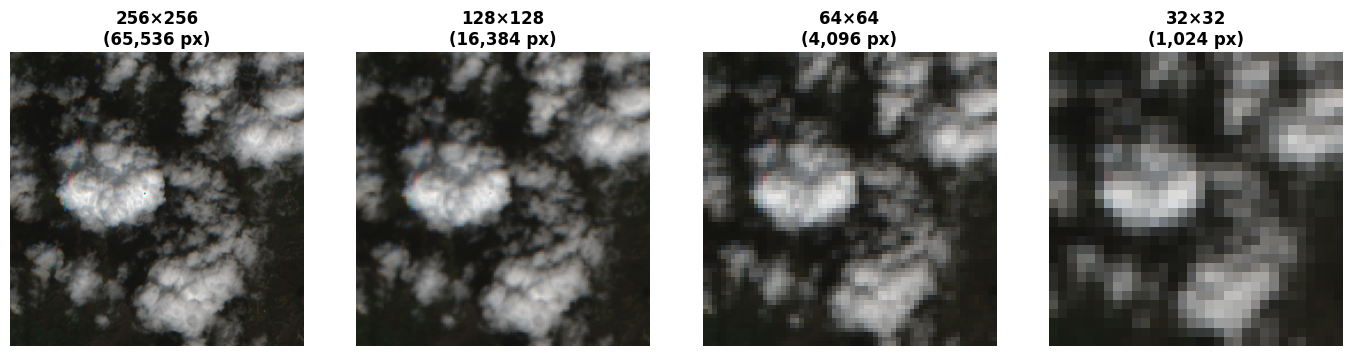

In [11]:
img_demo, ndvi_demo = images[2], labels[2]     #image #100

# A RESIZE — compare 4 sizes side by side
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5)) #
print("SIMPLE DATA MANIPULATION - RESIZING ")
for ax, sz in zip(axes, [256, 128, 64, 32]):
    ax.imshow(np.clip(resize(img_demo, (sz,sz), anti_aliasing=True), 0, 1)) # resizes original image to (sz x sz), makes sure the range is 0-1 and displays the resized image 
    ax.set_title(f"{sz}×{sz}\n({sz*sz:,} px)", fontweight="bold"); ax.axis("off")
plt.tight_layout(); plt.show()